In [1]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np

%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
#Read the FireCADRMSData Excel file
fire_data_sheet = pd.read_excel('GC_FireData.xlsx', engine='openpyxl', sheet_name=None)

In [3]:
#Obtain data in the individual sheets
fire_DA_data = fire_data_sheet['FireData_2024_05_30_DAUID']
lkp_codes = fire_data_sheet['Lkp_Codes']

In [4]:
fire_DA_data.shape

(40815, 21)

In [5]:
lkp_codes.shape

(438, 4)

In [6]:
fire_DA_data.head(10)

,OID_,unique_Id,inci_no,inci_type,alm_type,e911_used,Property_Loss_Value,Content_Loss_Value,Property_Loss_Value.1,Content_Loss_Value.1,...,Civilian_Injuries,prop_use,alm_dttm,disp_dttm,arv_dttm,ctrl_dttm,clr_dttm,DAUID,NEAR_X,NEAR_Y
0,1,500146,23-0000882,62,1.0,},0,0,0,0,...,0,909,2023-01-31 18:25:00,2023-01-31 18:24:00,2023-01-31 18:30:00,NaT,2023-01-31 19:04:00,35431321,-79.697447,44.360933
1,2,464928,22-0005859,910,9.0,|,0,0,0,0,...,0,901,2022-07-19 17:09:00,2022-07-19 16:41:00,2022-07-19 17:30:00,NaT,2022-07-19 18:32:00,NaN,-79.622728,44.336964
2,3,370846,20-0000020,898,3.0,Q,0,0,0,0,...,0,223,2020-01-01 14:40:00,2020-01-01 14:39:00,2020-01-01 14:45:00,NaT,2020-01-01 14:50:00,35431004,-79.667671,44.369634
3,4,371206,20-0000135,898,3.0,Q,0,0,0,0,...,0,323,2020-01-06 11:54:00,2020-01-06 11:53:00,2020-01-06 11:58:00,NaT,2020-01-06 12:16:00,35431004,-79.667671,44.369634
4,5,371480,20-0000236,898,3.0,Q,0,0,0,0,...,0,223,2020-01-10 02:43:00,2020-01-10 02:43:00,2020-01-10 02:50:00,NaT,2020-01-10 02:57:00,35431004,-79.667671,44.369634
5,6,371865,20-0000349,898,3.0,Q,0,0,0,0,...,0,223,2020-01-15 08:15:00,2020-01-15 08:14:00,2020-01-15 08:21:00,NaT,2020-01-15 08:24:00,35431004,-79.664749,44.366205
6,7,371972,20-0000386,898,3.0,Q,0,0,0,0,...,0,216,2020-01-16 09:37:00,2020-01-16 09:37:00,2020-01-16 09:43:00,NaT,2020-01-16 09:45:00,35431004,-79.667671,44.369634
7,8,373787,20-0000898,898,3.0,Q,0,0,0,0,...,0,301,2020-02-07 00:17:00,2020-02-07 00:17:00,2020-02-07 00:24:00,NaT,2020-02-07 00:26:00,35431373,-79.624102,44.342832
8,9,374522,20-0001118,898,3.0,Q,0,0,0,0,...,0,323,2020-02-16 09:48:00,2020-02-16 09:48:00,2020-02-16 09:57:00,NaT,2020-02-16 10:02:00,35431004,-79.667671,44.369634
9,10,375169,20-0001237,898,3.0,Q,0,0,0,0,...,0,323,2020-02-22 15:18:00,2020-02-22 15:18:00,2020-02-22 15:23:00,NaT,2020-02-22 15:25:00,35431004,-79.667671,44.369634


In [7]:
fire_DA_data.isnull().sum()

OID_                         0
unique_Id                    0
inci_no                      0
inci_type                    0
alm_type                     4
e911_used                  295
Property_Loss_Value          0
Content_Loss_Value           0
Property_Loss_Value.1        0
Content_Loss_Value.1         0
Civilian_Fatal               0
Civilian_Injuries            0
prop_use                     0
alm_dttm                     0
disp_dttm                    0
arv_dttm                   408
ctrl_dttm                40282
clr_dttm                     4
DAUID                      245
NEAR_X                       0
NEAR_Y                       0
dtype: int64

### There are missing values in alm_type, e911_used, arv_dttm, ctrl_dttm, clr_dttm and DAUID

In [8]:
fire_DA_data_cleaned = fire_DA_data.drop(['OID_', 'alm_type', 'e911_used', 'ctrl_dttm'], axis=1)

In [9]:
fire_DA_data_cleaned.head(10)

,unique_Id,inci_no,inci_type,Property_Loss_Value,Content_Loss_Value,Property_Loss_Value.1,Content_Loss_Value.1,Civilian_Fatal,Civilian_Injuries,prop_use,alm_dttm,disp_dttm,arv_dttm,clr_dttm,DAUID,NEAR_X,NEAR_Y
0,500146,23-0000882,62,0,0,0,0,0,0,909,2023-01-31 18:25:00,2023-01-31 18:24:00,2023-01-31 18:30:00,2023-01-31 19:04:00,35431321,-79.697447,44.360933
1,464928,22-0005859,910,0,0,0,0,0,0,901,2022-07-19 17:09:00,2022-07-19 16:41:00,2022-07-19 17:30:00,2022-07-19 18:32:00,NaN,-79.622728,44.336964
2,370846,20-0000020,898,0,0,0,0,0,0,223,2020-01-01 14:40:00,2020-01-01 14:39:00,2020-01-01 14:45:00,2020-01-01 14:50:00,35431004,-79.667671,44.369634
3,371206,20-0000135,898,0,0,0,0,0,0,323,2020-01-06 11:54:00,2020-01-06 11:53:00,2020-01-06 11:58:00,2020-01-06 12:16:00,35431004,-79.667671,44.369634
4,371480,20-0000236,898,0,0,0,0,0,0,223,2020-01-10 02:43:00,2020-01-10 02:43:00,2020-01-10 02:50:00,2020-01-10 02:57:00,35431004,-79.667671,44.369634
5,371865,20-0000349,898,0,0,0,0,0,0,223,2020-01-15 08:15:00,2020-01-15 08:14:00,2020-01-15 08:21:00,2020-01-15 08:24:00,35431004,-79.664749,44.366205
6,371972,20-0000386,898,0,0,0,0,0,0,216,2020-01-16 09:37:00,2020-01-16 09:37:00,2020-01-16 09:43:00,2020-01-16 09:45:00,35431004,-79.667671,44.369634
7,373787,20-0000898,898,0,0,0,0,0,0,301,2020-02-07 00:17:00,2020-02-07 00:17:00,2020-02-07 00:24:00,2020-02-07 00:26:00,35431373,-79.624102,44.342832
8,374522,20-0001118,898,0,0,0,0,0,0,323,2020-02-16 09:48:00,2020-02-16 09:48:00,2020-02-16 09:57:00,2020-02-16 10:02:00,35431004,-79.667671,44.369634
9,375169,20-0001237,898,0,0,0,0,0,0,323,2020-02-22 15:18:00,2020-02-22 15:18:00,2020-02-22 15:23:00,2020-02-22 15:25:00,35431004,-79.667671,44.369634


In [10]:
lkp_codes.isnull().sum()

category    0
grp         0
code        0
descript    0
dtype: int64

### Rename columns

In [11]:
fire_DA_data_cleaned.rename(columns = {'alm_dttm': 'Received_Datetime', 
                                       'disp_dttm': 'Dispatched_Datetime',
                                       'arv_dttm': 'Arrival_Datetime',
                                       'clr_dttm': 'Cleared_Datetime',
                                       'NEAR_X': 'Longitude',
                                       'NEAR_Y': 'Latitude'
                                      }, inplace=True)

In [12]:
fire_DA_data_cleaned.head(10)

,unique_Id,inci_no,inci_type,Property_Loss_Value,Content_Loss_Value,Property_Loss_Value.1,Content_Loss_Value.1,Civilian_Fatal,Civilian_Injuries,prop_use,Received_Datetime,Dispatched_Datetime,Arrival_Datetime,Cleared_Datetime,DAUID,Longitude,Latitude
0,500146,23-0000882,62,0,0,0,0,0,0,909,2023-01-31 18:25:00,2023-01-31 18:24:00,2023-01-31 18:30:00,2023-01-31 19:04:00,35431321,-79.697447,44.360933
1,464928,22-0005859,910,0,0,0,0,0,0,901,2022-07-19 17:09:00,2022-07-19 16:41:00,2022-07-19 17:30:00,2022-07-19 18:32:00,NaN,-79.622728,44.336964
2,370846,20-0000020,898,0,0,0,0,0,0,223,2020-01-01 14:40:00,2020-01-01 14:39:00,2020-01-01 14:45:00,2020-01-01 14:50:00,35431004,-79.667671,44.369634
3,371206,20-0000135,898,0,0,0,0,0,0,323,2020-01-06 11:54:00,2020-01-06 11:53:00,2020-01-06 11:58:00,2020-01-06 12:16:00,35431004,-79.667671,44.369634
4,371480,20-0000236,898,0,0,0,0,0,0,223,2020-01-10 02:43:00,2020-01-10 02:43:00,2020-01-10 02:50:00,2020-01-10 02:57:00,35431004,-79.667671,44.369634
5,371865,20-0000349,898,0,0,0,0,0,0,223,2020-01-15 08:15:00,2020-01-15 08:14:00,2020-01-15 08:21:00,2020-01-15 08:24:00,35431004,-79.664749,44.366205
6,371972,20-0000386,898,0,0,0,0,0,0,216,2020-01-16 09:37:00,2020-01-16 09:37:00,2020-01-16 09:43:00,2020-01-16 09:45:00,35431004,-79.667671,44.369634
7,373787,20-0000898,898,0,0,0,0,0,0,301,2020-02-07 00:17:00,2020-02-07 00:17:00,2020-02-07 00:24:00,2020-02-07 00:26:00,35431373,-79.624102,44.342832
8,374522,20-0001118,898,0,0,0,0,0,0,323,2020-02-16 09:48:00,2020-02-16 09:48:00,2020-02-16 09:57:00,2020-02-16 10:02:00,35431004,-79.667671,44.369634
9,375169,20-0001237,898,0,0,0,0,0,0,323,2020-02-22 15:18:00,2020-02-22 15:18:00,2020-02-22 15:23:00,2020-02-22 15:25:00,35431004,-79.667671,44.369634


In [13]:
fire_DA_data_cleaned.dtypes

unique_Id                         int64
inci_no                          object
inci_type                         int64
Property_Loss_Value               int64
Content_Loss_Value                int64
Property_Loss_Value.1             int64
Content_Loss_Value.1              int64
Civilian_Fatal                    int64
Civilian_Injuries                 int64
prop_use                          int64
Received_Datetime        datetime64[ns]
Dispatched_Datetime      datetime64[ns]
Arrival_Datetime         datetime64[ns]
Cleared_Datetime         datetime64[ns]
DAUID                            object
Longitude                       float64
Latitude                        float64
dtype: object

In [14]:
fire_DA_data_cleaned.loc[fire_DA_data_cleaned['unique_Id'] == 406145]

,unique_Id,inci_no,inci_type,Property_Loss_Value,Content_Loss_Value,Property_Loss_Value.1,Content_Loss_Value.1,Civilian_Fatal,Civilian_Injuries,prop_use,Received_Datetime,Dispatched_Datetime,Arrival_Datetime,Cleared_Datetime,DAUID,Longitude,Latitude
62,406145,21-0001079,898,0,0,0,0,0,0,402,2021-02-23 19:33:00,2021-02-23 19:33:00,2021-02-23 19:37:00,2021-02-23 19:45:00,00:00:00,-79.622728,44.336964


In [15]:
DAUID_index = fire_DA_data_cleaned[fire_DA_data_cleaned['unique_Id'] == 406145].index
fire_DA_data_cleaned.drop(DAUID_index, inplace=True)

In [16]:
fire_DA_data_cleaned.shape

(40814, 17)

In [17]:
fire_DA_data_cleaned['DAUID'].value_counts()

DAUID
35431060    1306
35431059    1275
35431324    1264
35431321    1163
35431050     871
            ... 
35430651      37
35431141      33
35430674      29
35431074      23
35431320      22
Name: count, Length: 243, dtype: int64

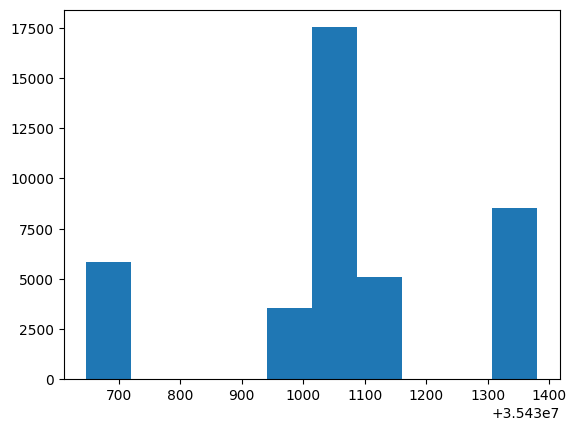

In [18]:
plt.hist(fire_DA_data_cleaned['DAUID'])
plt.show()

In [20]:
fire_DA_data_cleaned.groupby('DAUID').agg({'Longitude': ['min', 'max'], 'Latitude': ['min', 'max']})

Longitude              Latitude           
                min        max        min        max
DAUID                                               
35430647 -79.722924 -79.715360  44.405820  44.413951
35430648 -79.726433 -79.721169  44.405469  44.410158
35430649 -79.724690 -79.719464  44.403918  44.407687
35430650 -79.729096 -79.721376  44.401194  44.405993
35430651 -79.729096 -79.725922  44.401402  44.406990
...             ...        ...        ...        ...
35431370 -79.734327 -79.720177  44.341294  44.352206
35431371 -79.727044 -79.720177  44.350530  44.352871
35431372 -79.737163 -79.719352  44.331807  44.339693
35431373 -79.650329 -79.585882  44.332995  44.369832
35431380 -79.732780 -79.655998  44.298919  44.327700

[243 rows x 4 columns]

In [21]:
fire_DA_data_cleaned.to_excel('FireCADRMS_cleaned.xlsx')